## 1) Load Data

Load data, filter by removing unnecessary columns(data), and process the rest of it

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

In [ ]:
# Reset to default white theme and explicitly set face colors instead of using system theme colors
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

In [19]:
pwd

'/home/yuchen/deeplab-insect-locomotion-analysis'

In [ ]:
# FILE_DIR = str(Path('path')) # Replace 'path' with the actual path to your directory

FILES_DIR = [str(path) for path in Path('videos').glob('IMG_*_*seconds_*.csv')]
FILES_DIR.sort()

In [ ]:
df = pd.read_csv(FILE_DIR)

In [ ]:
# Loading multiple dataframes from multiple files
df_array = []
for file in FILES_DIR:
    df_array.append(pd.read_csv(file))

In [ ]:
bodyparts= df.iloc[0,1:]
coords = df.iloc[1,1:]

df_filtered = df.iloc[2:].reset_index(drop=True) # remove the first two rows which are not needed

flat_cols = ['frame'] + [
    f'{bp}_{c}' for bp, c in zip(bodyparts, coords)
]

df_filtered.columns = flat_cols
df_filtered = df_filtered.astype({col: float for col in df_filtered.columns if col != 'frame'})
df_filtered.drop(list(df_filtered.filter(regex='likelihood')), axis=1, inplace=True)

In [91]:
df_filtered_array = []

for df in df_array:
    bodyparts= df.iloc[0,1:]
    coords = df.iloc[1,1:]

    df_filtered = df.iloc[2:].reset_index(drop=True) # remove the first two rows which are not needed

    flat_cols = ['frame'] + [
        f'{bp}_{c}' for bp, c in zip(bodyparts, coords)
    ]

    df_filtered.columns = flat_cols
    df_filtered = df_filtered.astype({col: float for col in df_filtered.columns if col != 'frame'})
    df_filtered.drop(list(df_filtered.filter(regex='likelihood')), axis=1, inplace=True)

    df_filtered_array.append(df_filtered)

In [ ]:
df_filtered['TCTC_vector_x'] = df_filtered['TC_Middle_Leg_x'] - df_filtered['TC_Front_Leg_x'] 
df_filtered['TCTC_vector_y'] = df_filtered['TC_Middle_Leg_y'] - df_filtered['TC_Front_Leg_y']

df_filtered['TCFT_vector_x'] = df_filtered['TC_Middle_Leg_x'] - df_filtered['FT_Middle_Leg_x']
df_filtered['TCFT_vector_y'] = df_filtered['TC_Middle_Leg_y'] - df_filtered['FT_Middle_Leg_y']

# Dot product and magnitudes of the two vectors to get the cosine of the angle between them
df_filtered['dot_product'] = df_filtered['TCTC_vector_x'] * df_filtered['TCFT_vector_x'] + df_filtered['TCTC_vector_y'] * df_filtered['TCFT_vector_y']

df_filtered['TCTC_magnitude'] = (df_filtered['TCTC_vector_x']**2 + df_filtered['TCTC_vector_y']**2)**0.5
df_filtered['TCFT_magnitude'] = (df_filtered['TCFT_vector_x']**2 + df_filtered['TCFT_vector_y']**2)**0.5


df_filtered['cosine_angle'] = (df_filtered['dot_product'] / (df_filtered['TCTC_magnitude'] * df_filtered['TCFT_magnitude'])).clip(-1.0, 1.0)
df_filtered['angle'] = np.arccos(df_filtered['cosine_angle']) * 180 / np.pi

In [92]:
for df_filtered in df_filtered_array:
    
    df_filtered['TCTC_vector_x'] = df_filtered['TC_Middle_Leg_x'] - df_filtered['TC_Front_Leg_x'] 
    df_filtered['TCTC_vector_y'] = df_filtered['TC_Middle_Leg_y'] - df_filtered['TC_Front_Leg_y']

    df_filtered['TCFT_vector_x'] = df_filtered['TC_Middle_Leg_x'] - df_filtered['FT_Middle_leg_x']
    df_filtered['TCFT_vector_y'] = df_filtered['TC_Middle_Leg_y'] - df_filtered['FT_Middle_leg_y']

    # Dot product and magnitudes of the two vectors to get the cosine of the angle between them
    df_filtered['dot_product'] = df_filtered['TCTC_vector_x'] * df_filtered['TCFT_vector_x'] + df_filtered['TCTC_vector_y'] * df_filtered['TCFT_vector_y']

    df_filtered['TCTC_magnitude'] = (df_filtered['TCTC_vector_x']**2 + df_filtered['TCTC_vector_y']**2)**0.5
    df_filtered['TCFT_magnitude'] = (df_filtered['TCFT_vector_x']**2 + df_filtered['TCFT_vector_y']**2)**0.5


    df_filtered['cosine_angle'] = (df_filtered['dot_product'] / (df_filtered['TCTC_magnitude'] * df_filtered['TCFT_magnitude'])).clip(-1.0, 1.0)
    df_filtered['angle'] = np.arccos(df_filtered['cosine_angle']) * 180 / np.pi

    

In [ ]:
df_filtered['angle'].plot(title='Angle between TCTC and TCFT vectors over time', xlabel='Frame', ylabel='Angle (degrees)')

In [ ]:
def clean_filename(text):
    # Matches optional 'I', 'MG', numbers, seconds, and the name
    match = re.match(r"^I?MG_\d+_(\d+)(seconds)_([a-zA-Z]+)", text)
    
    if match:
        num, time_suffix, name = match.groups()
        
        # Convert "01" to "0.1", otherwise keep as is (e.g., "3")
        if len(num) == 2 and num.startswith('0'):
            num = f"0.{num[1]}"
            
        # Format strings
        # formatted_time = f"{num} {time_suffix.capitalize()}" # Uses more descipritve name e.g. '1 seconds Retractor'
        formatted_time = f"{num}s" # uses more compact naming '1s Retractor'
        formatted_name = name.capitalize()
        
        return f"{formatted_time} {formatted_name}"
    return text

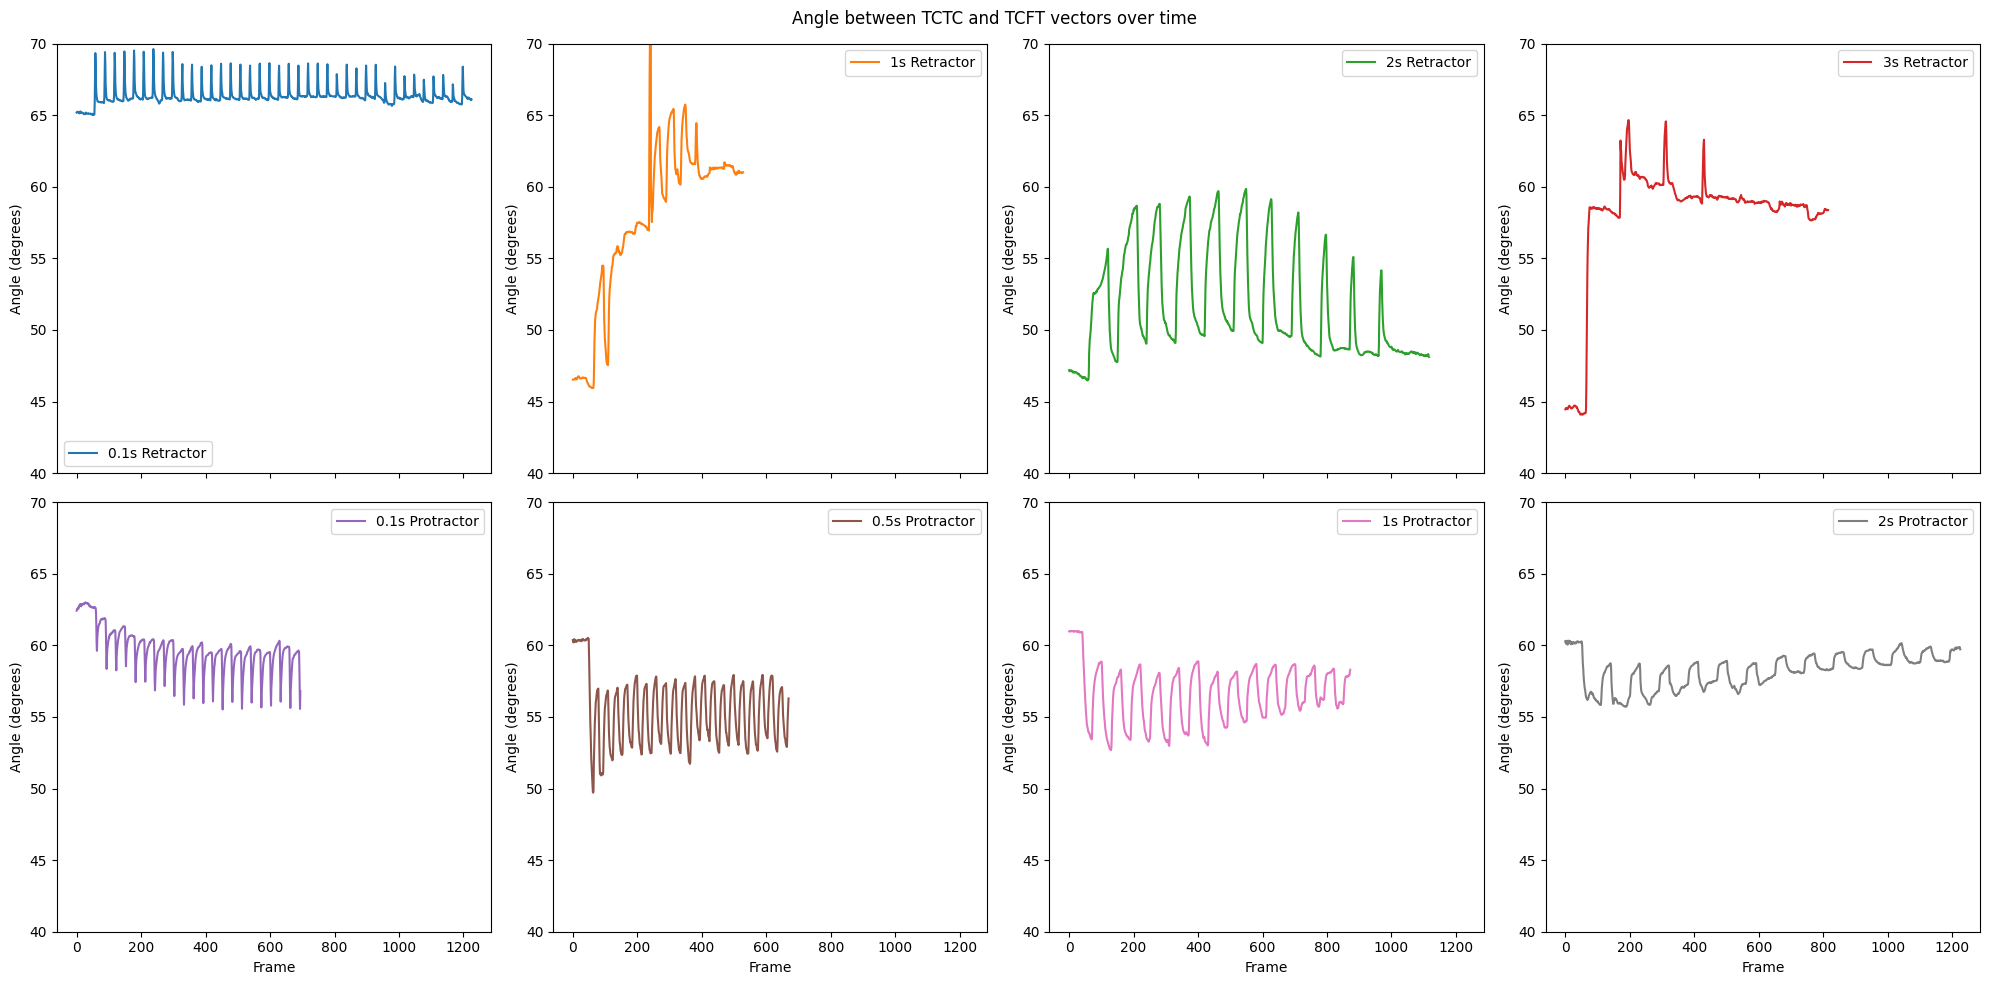

In [ ]:
# Create new dataframe that combines all dataframes' angle column into one
angle_df = pd.DataFrame()

for file_path, df in zip(FILES_DIR, df_filtered_array):
    clean_label = Path(file_path).name.split('DLC')[0] # extract the meaningful name from filename
    formatted_label = clean_filename(clean_label) # format the name of columns since they will be used in legend of the plots
    angle_df[formatted_label] = df['angle'] # rename

axes = angle_df.plot(
    title='Angle between TCTC and TCFT vectors over time', 
    xlabel='Frame', 
    ylabel='Angle (degrees)', 
    subplots=True, 
    layout=(2, 4), 
    figsize=(20, 10)
)

# Set a y axis limit so the data can be compared just by eyes
for ax in axes.flatten():
    ax.set_ylim(40, 70)

plt.tight_layout()
plt.show()

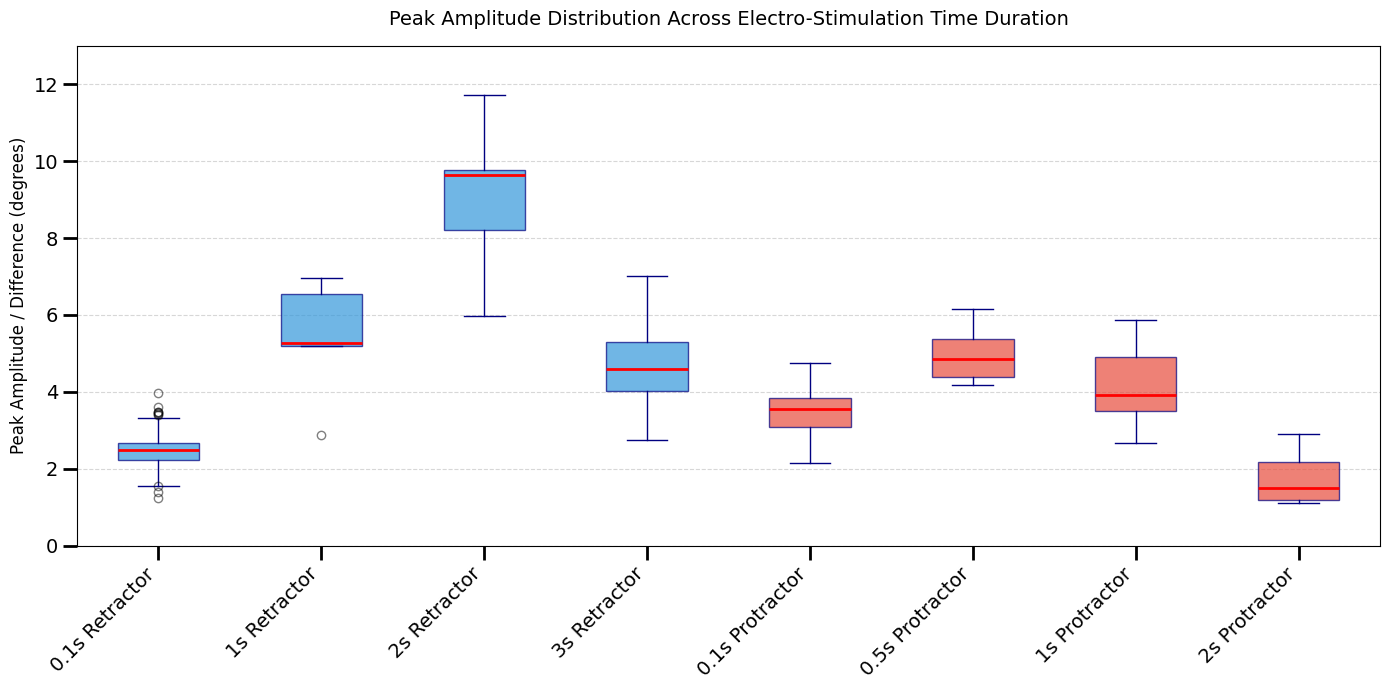

In [ ]:
from scipy.signal import find_peaks

# Collect peak differences for each column
all_peak_diffs = []

for col in angle_df.columns:
    signal = angle_df[col].dropna().values
    peaks, properties = find_peaks(signal, prominence=1)
    peak_differences = properties['prominences']
    all_peak_diffs.append(peak_differences)

plt.figure(figsize=(14, 7))


boxes = plt.boxplot(
    all_peak_diffs,
    patch_artist=True,  # Enables colored box fill
    boxprops=dict(facecolor='lightblue', color='navy', alpha=0.7),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='navy'),
    capprops=dict(color='navy'),
    flierprops=dict(marker='o', color='gray', alpha=0.5)
)

retractor_color = '#3498db'   # Soft Blue for first 4 (Retractor)
protractor_color = '#e74c3c'  # Soft Red for remaining (Protractor)

# Loop over each box patch and apply colors by index
for i, box in enumerate(boxes['boxes']):
    if i < 4:
        box.set_facecolor(retractor_color)
    else:
        box.set_facecolor(protractor_color)
    box.set_alpha(0.7)
plt.ylim(0, 13)


# Plot formatting
plt.xticks(ticks=range(1, len(angle_df.columns) + 1), labels=angle_df.columns, rotation=45, ha='right')
plt.title('Peak Amplitude Distribution Across Electro-Stimulation Time Duration', fontsize=14, pad=15)
plt.ylabel('Peak Amplitude / Difference (degrees)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tick_params(axis='both', which='major', labelsize=14, length=10, width=2)
plt.savefig(desired_path, format='png',bbox_inches='tight')
plt.tight_layout()
plt.show()